In [10]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
import pickle

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow_hub as hub
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix

assert tf.__version__.startswith('2'), f'TF 2.x required, got {tf.__version__}'
print(f'TensorFlow: {tf.__version__}')
print(f'GPUs available: {tf.config.list_physical_devices("GPU")}')


TensorFlow: 2.21.0
GPUs available: []


In [11]:
# ── Data paths ───────────────────────────────────────────────────────────────
TRAIN_PKL        = '../data/folds-w-meta.pkl'   # pickle with train folds
TEST_PKL         = '../data/test-w-meta.pkl'     # pickle with test fold
FOLDER_IMAGE_DIR = '../data/classes/'            # optional extra labelled images

# ── Image / training hyper-parameters ────────────────────────────────────────
CLASSIFY_IMAGE_SIZE   = (75, 200)   # native resolution in the pkl files
ESTIMATE_IMAGE_SIZE   = (224, 224)  # EfficientNetB0 expects 224x224
BATCH_SIZE            = 32
CLASSIFIER_EPOCHS     = 10
ESTIMATOR_EPOCHS      = 10
SEED                = 42
EFFNET_LITE0_URL    = 'https://tfhub.dev/tensorflow/efficientnet/lite0/feature-vector/2'

# ── Size-bin definitions ──────────────────────────────────────────────────────
# Upper bound in mm → label string in cm

### Updated bin edges and labels to include more bins for better resolution
BIN_EDGES  = [250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 800, 900]
BIN_LABELS = ['25', '30', '35', '40', '45', '50', '55', '60', '65', '70', '80', '90']

### Original Bin edges and labels (edges in mm, labels in cm)
#BIN_EDGES  = [100, 150, 200, 250, 300, 350, 400, 500, 600, 700]
#BIN_LABELS = [ '10', '15', '20', '25', '30', '35', '40', '50', '60', '70']
NUM_SIZE_BINS = len(BIN_LABELS)

def length_to_bin(length_mm):
    """Map a length in mm to a size-bin index. Returns None if out of range."""
    for i, edge in enumerate(BIN_EDGES):
        if length_mm <= edge:
            return i
    return None


In [12]:
def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f, encoding='latin1')  # latin1 handles Python-2-saved pkls

train_folds = load_pkl(TRAIN_PKL)
test_folds  = load_pkl(TEST_PKL)

print(f'Train folds: {len(train_folds)}')
print(f'Keys per fold: {list(train_folds[0].keys())}')
print(f'Images in fold 0: {train_folds[0]["data"].shape}')


Train folds: 10
Keys per fold: ['fold', 'length', 'weight', 'source', 'girth', 'data', 'id', 'class']
Images in fold 0: (63, 9, 75, 200, 3)


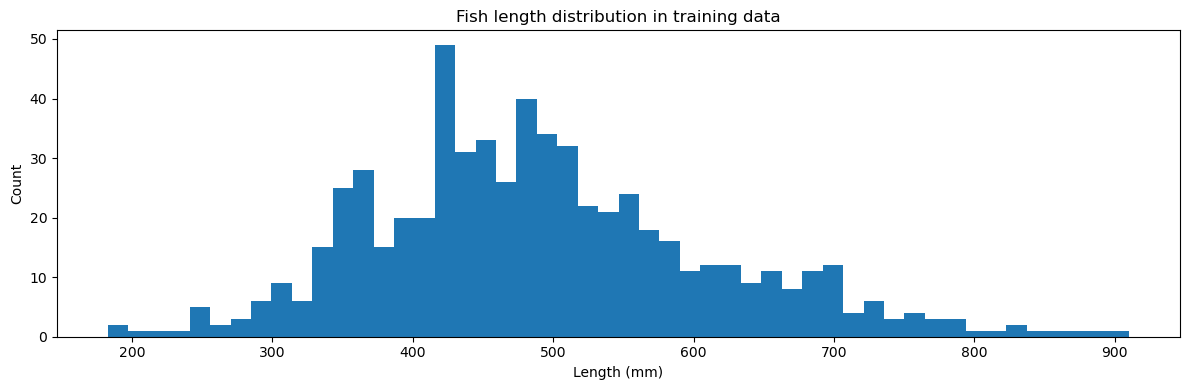

Min: 183mm, Max: 910mm, N: 623


In [13]:
all_lengths = []
for fold in train_folds:
    for length in fold['length']:
        if length is None or str(length).strip() in ('', 'NA'): continue
        all_lengths.append(float(length))

plt.figure(figsize=(12, 4))
plt.hist(all_lengths, bins=50)
plt.xlabel('Length (mm)'); plt.ylabel('Count')
plt.title('Fish length distribution in training data')
plt.tight_layout(); plt.show()

print(f'Min: {min(all_lengths):.0f}mm, Max: {max(all_lengths):.0f}mm, N: {len(all_lengths)}')

# Classification

In [14]:
TRAIN_FOLDS = list(range(0, 8))
VAL_FOLD    = 8
TEST_FOLD   = 9

def load_classification_folds(fold_indices, metadata, label_key='class'):
    """Unpack fold dicts into flat (N*9, 75, 200, 3) image arrays."""
    X_list, y_list = [], []
    for i in fold_indices:
        X = metadata[i]['data']       # (N, 9, 75, 200, 3) — 9 views per fish
        y = metadata[i][label_key]    # (N,)
        X = X.reshape(-1, 75, 200, 3)
        y = np.repeat(y, 9)
        X_list.append(X)
        y_list.append(y)
    return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0)

X_cls_train, y_cls_train = load_classification_folds(TRAIN_FOLDS, train_folds)
X_cls_val,   y_cls_val   = load_classification_folds([VAL_FOLD],  train_folds)
X_cls_test,  y_cls_test  = load_classification_folds([TEST_FOLD], train_folds)

print(f'Train: {X_cls_train.shape}, Val: {X_cls_val.shape}, Test: {X_cls_test.shape}')

# Normalise
X_cls_train = X_cls_train.astype('float32') / 255.0
X_cls_val   = X_cls_val.astype('float32')   / 255.0
X_cls_test  = X_cls_test.astype('float32')  / 255.0

# Encode string species labels → integers
species_le = LabelEncoder()
species_le.fit(np.concatenate([y_cls_train, y_cls_val, y_cls_test]))
y_cls_train_enc = species_le.transform(y_cls_train)
y_cls_val_enc   = species_le.transform(y_cls_val)
y_cls_test_enc  = species_le.transform(y_cls_test)
NUM_SPECIES = len(species_le.classes_)

print(f'Species ({NUM_SPECIES}): {species_le.classes_}')


Train: (4491, 75, 200, 3), Val: (558, 75, 200, 3), Test: (558, 75, 200, 3)
Species (22): ['BHC' 'BUF' 'CC' 'CCF' 'CWS' 'FWD' 'GC' 'GF' 'GS' 'LNG' 'LNS' 'NHS' 'NP'
 'QBS' 'RHS' 'RRS' 'SC' 'SL' 'SMB' 'WB' 'WP' 'WYE']


In [15]:
import keras


classifier = keras.models.load_model("models/classifier.keras")
classifier.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 75, 200,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 75, 200,   │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 75, 200,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 37, 100,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 37, 100,   │      9,248 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 100,   │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 37, 100,   │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 100,   │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 37, 100,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 37, 100,   │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 18, 50,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 18, 50,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 18, 50,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 18, 50,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 18, 50,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 18, 50,    │      2,112 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 18, 50,    │          0 │ batch_normalizat

 Total params: 952,964 (3.64 MB)

 Trainable params: 317,334 (1.21 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 634,670 (2.42 MB)

# Size Estimator (Bins)

In [16]:
TRAIN_FOLDS = list(range(0, 9))
VAL_FOLDS   = [9]

In [17]:
def folds_to_arrays(folds, fold_indices=None):
    """
    Unpack the listed folds into (N, 224, 224, 3) float32 images and (N,) int bin labels.
    Each fish contributes 9 image entries (one per scanner view).
    """
    if fold_indices is None:
        fold_indices = list(range(len(folds)))
    X, y = [], []
    skipped_fish = 0
    for fi in fold_indices:
        fold = folds[fi]
        for i, raw in enumerate(fold['data']):           # raw: (9, 75, 200, 3)
            length = fold['length'][i]
            if length is None or str(length).strip() in ('', 'NA'):
                skipped_fish += 1; continue
            bin_idx = length_to_bin(float(length))
            if bin_idx is None:
                skipped_fish += 1; continue

            # Each fish has 9 views — emit one example per view
            for view_idx in range(raw.shape[0]):
                img = raw[view_idx].astype(np.float32)   # (75, 200, 3)
                img_resized = tf.image.resize(img, ESTIMATE_IMAGE_SIZE).numpy()
                X.append(img_resized)
                y.append(bin_idx)

    print(f'  Loaded {len(X)} images from {len(X)//9} fish, skipped {skipped_fish} fish')
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

In [18]:
X_all, y_all = folds_to_arrays(train_folds + test_folds)
X_train, X_temp, y_train, y_temp = train_test_split(X_all, y_all, test_size=0.2)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

print(f'\nTrain: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')
print(f'Train bin counts: {np.bincount(y_train, minlength=NUM_SIZE_BINS)}')
print(f'Val   bin counts: {np.bincount(y_val,   minlength=NUM_SIZE_BINS)}')
print(f'Test  bin counts: {np.bincount(y_test,  minlength=NUM_SIZE_BINS)}')

  Loaded 6237 images from 693 fish, skipped 1 fish

Train: 4989  Val: 624  Test: 624
Train bin counts: [ 64 112 338 569 931 939 685 479 313 292 195  72]
Val   bin counts: [ 11   9  26  71 110 108 103  60  51  31  36   8]
Test  bin counts: [  6  14  50  62 120 123  85  55  32  37  30  10]


In [19]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
            .shuffle(len(X_train), seed=SEED)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))
val_ds   = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
            .batch(BATCH_SIZE).cache().prefetch(AUTOTUNE))
test_ds  = (tf.data.Dataset.from_tensor_slices((X_test, y_test))
            .batch(BATCH_SIZE).cache().prefetch(AUTOTUNE))

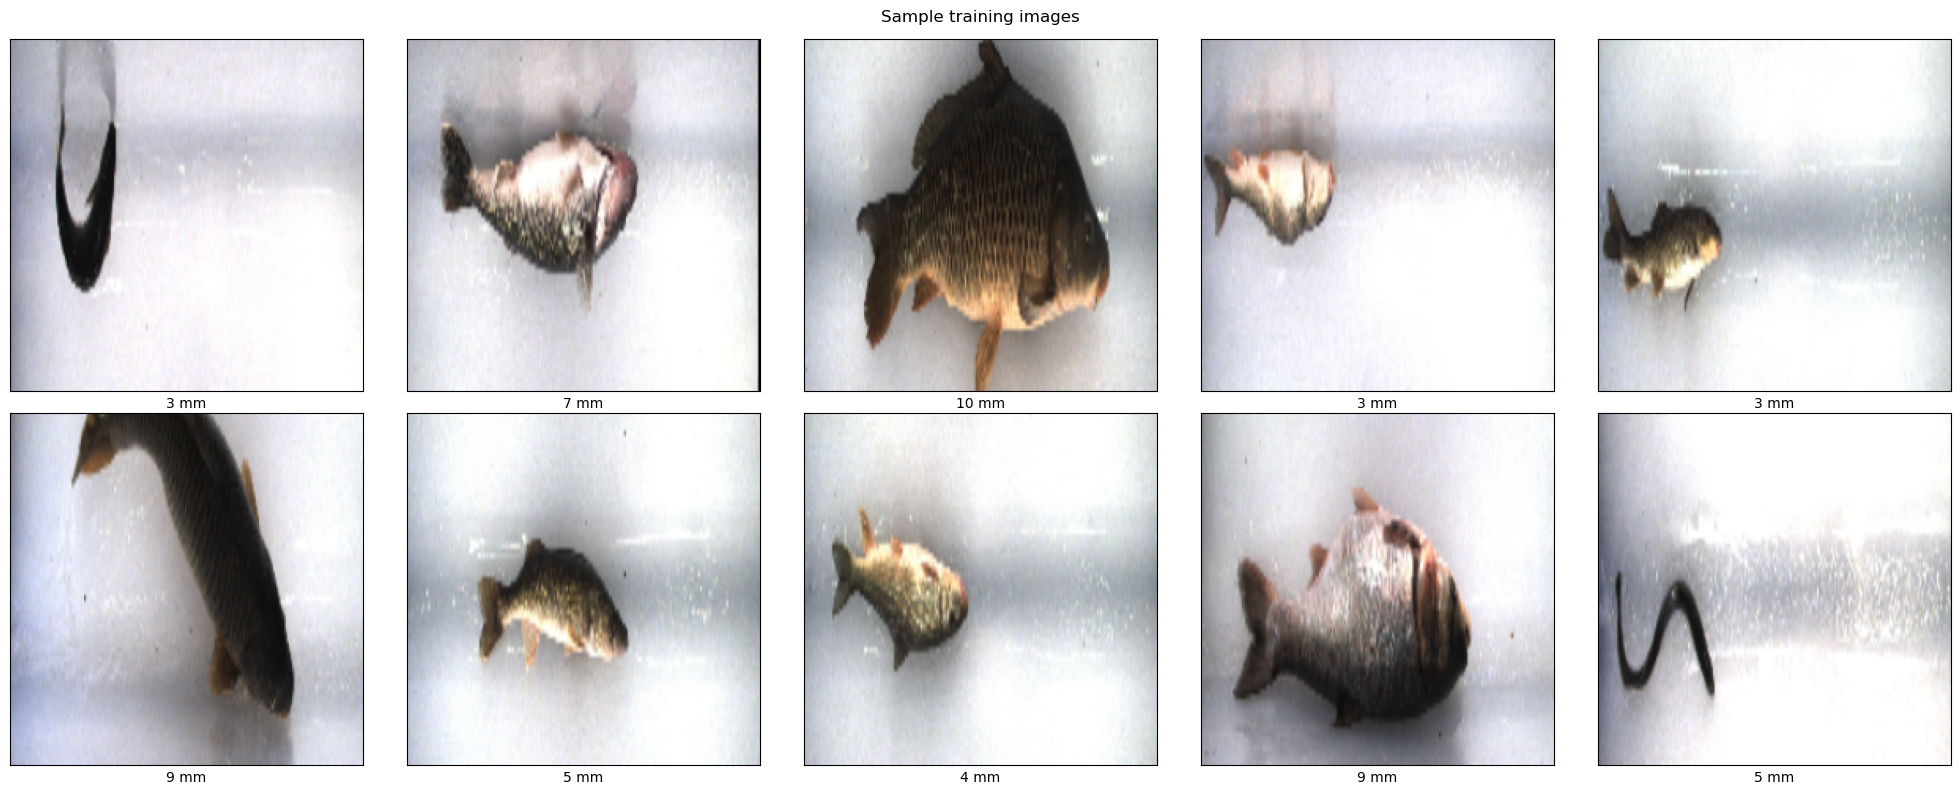

In [20]:
plt.figure(figsize=(20, 8))
for imgs, lbls in train_ds.take(1):
    for i in range(min(10, imgs.shape[0])):
        plt.subplot(2, 5, i + 1)
        plt.xticks([]); plt.yticks([]); plt.grid(False)
        plt.imshow(imgs[i].numpy().astype('uint8'))
        plt.xlabel(f'{lbls[i].numpy():.0f} mm')
plt.suptitle('Sample training images')
plt.tight_layout(); plt.show()

## Build Estimator Model

In [21]:
def build_estimator(num_classes, trainable_backbone=False):
    backbone = hub.KerasLayer(
        EFFNET_LITE0_URL,
        trainable=trainable_backbone,
        input_shape=ESTIMATE_IMAGE_SIZE + (3,),
    )
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=ESTIMATE_IMAGE_SIZE + (3,)),
        tf.keras.layers.Rescaling(1.0 / 255.0),   # [0,255] → [0,1] for Lite0
        backbone,
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation='softmax'),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

estimator = tf.keras.models.load_model("models/estimator_bins.keras", custom_objects={"KerasLayer": hub.KerasLayer}) #build_estimator(NUM_SIZE_BINS, trainable_backbone=False)
estimator.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 keras_layer (KerasLayer)    (None, 1280)              3413024   
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 12)                15372     
                                                                 
Total params: 3428396 (13.08 MB)
Trainable params: 15372 (60.05 KB)
Non-trainable params: 3413024 (13.02 MB)
_________________________________________________________________


## Train Model

In [22]:
# Class weights for bin imbalance (small/large fish are rare in Silva's data)
unique_bins = np.unique(y_train)
weights_arr = compute_class_weight('balanced', classes=unique_bins, y=y_train)
class_weights = dict(zip(unique_bins.tolist(), weights_arr.tolist()))
for c in range(NUM_SIZE_BINS):
    class_weights.setdefault(c, 1.0)
print(f'Class weights: {class_weights}')

early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

history = estimator.fit(
    train_ds,
    validation_data=val_ds,
    epochs=ESTIMATOR_EPOCHS
    # Below options not used by Silva but do improve accuracy
    #class_weight=class_weights,
    #callbacks=[early_stop],
)

Class weights: {0: 6.49609375, 1: 3.7120535714285716, 2: 1.2300295857988166, 3: 0.7306678383128296, 4: 0.44656283566058, 5: 0.44275825346112885, 6: 0.6069343065693431, 7: 0.8679540709812108, 8: 1.3282747603833867, 9: 1.4238013698630136, 10: 2.132051282051282, 11: 5.774305555555555}
Epoch 1/10



156/156 [==============================] - 18s 107ms/step - loss: 1.0824 - accuracy: 0.5961 - val_loss: 1.0606 - val_accuracy: 0.5849
Epoch 2/10
156/156 [==============================] - 16s 104ms/step - loss: 1.0270 - accuracy: 0.6226 - val_loss: 1.0301 - val_accuracy: 0.6154
Epoch 3/10
156/156 [==============================] - 17s 106ms/step - loss: 0.9933 - accuracy: 0.6314 - val_loss: 1.0309 - val_accuracy: 0.6234
Epoch 4/10
156/156 [==============================] - 16s 104ms/step - loss: 0.9531 - accuracy: 0.6434 - val_loss: 1.0238 - val_accuracy: 0.6378
Epoch 5/10
156/156 [==============================] - 16s 100ms/step - loss: 0.9231 - accuracy: 0.6607 - val_loss: 1.0084 - val_accuracy: 0.6122
Epoch 6/10
156/156 [==============================] - 16s 101ms/step - loss: 0.8894 - accuracy: 0.6669 - val_loss: 1.0008 - val_accuracy: 0.6330
Epoch 7/10
156/156 [==============================] - 16s 102ms/step - loss: 0.8551 - accuracy: 0.6889 - val_loss: 0.9823 - val_accuracy: 0.6

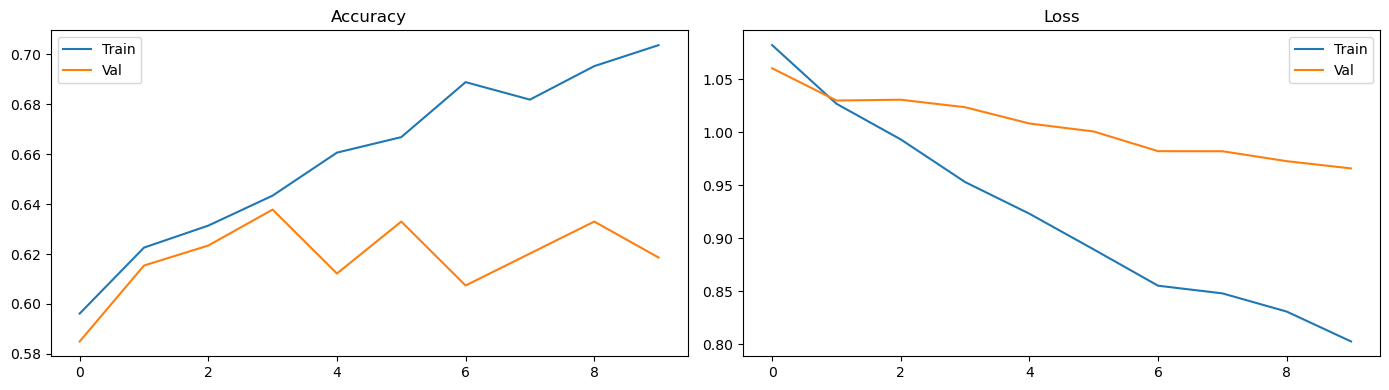

Train  — loss: 0.6976, accuracy: 78.31%
Val    — loss: 0.9660, accuracy: 61.86%
Test   — loss: 0.9066, accuracy: 67.15%


In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy'); ax1.legend()
ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss'); ax2.legend()
plt.tight_layout(); plt.show()

for ds, name in [(train_ds, 'Train'), (val_ds, 'Val'), (test_ds, 'Test')]:
    loss, acc = estimator.evaluate(ds, verbose=0)
    print(f'{name:<6} — loss: {loss:.4f}, accuracy: {acc:.2%}')

## Combined Inference

Blends the estimator's softmax output with the classifier's species-informed size distribution. **`alpha`** is the weight on the **estimator**; `(1 - alpha)` is the weight on the species-informed prior (`SPECIES_SIZE_PRIOR` from `configs/species_priors_by_code.yaml`).

- **Baselines:** `α=1.0` (estimator only), `α=0.0` (prior only)
- **Sweep:** test many `α` values on the aligned test set and pick the best for the confusion matrix

In [24]:
# ── Biological priors: P(size bin | species) ───────────────────────────────────
from pathlib import Path

PRIORS_BY_CODE_PATH = Path('../configs/species_priors_by_code.yaml')


def load_species_priors_by_code(path):
    """Load mean/min/max priors from simple YAML (no PyYAML dependency)."""
    priors = {}
    species = None
    for raw in Path(path).read_text().splitlines():
        line = raw.split('#', 1)[0].strip()
        if not line:
            continue
        if line.endswith(':') and ' ' not in line.rstrip(':'):
            species = line[:-1].strip()
            priors[species] = {}
            continue
        if species is None:
            continue
        key, _, val = line.partition(':')
        if val.strip():
            priors[species][key.strip()] = float(val.strip())
    return priors


def build_prior_matrix(species_classes, bin_labels, priors_by_code, sigma_scale=0.25):
    """Truncated Gaussian over bin centers; uniform row if species stats missing."""
    bin_centers = np.array([float(label) for label in bin_labels], dtype=np.float32)
    num_species = len(species_classes)
    num_bins = len(bin_labels)
    matrix = np.zeros((num_species, num_bins), dtype=np.float32)
    uniform = np.full(num_bins, 1.0 / num_bins, dtype=np.float32)

    for i, code in enumerate(species_classes):
        stats = priors_by_code.get(code)
        if not stats:
            matrix[i] = uniform
            continue
        mu = stats['mean_length_cm']
        lo = stats['min_length_cm']
        hi = stats['max_length_cm']
        sigma = max((hi - lo) * sigma_scale, 1.0)
        w = np.exp(-0.5 * ((bin_centers - mu) / sigma) ** 2)
        w *= (bin_centers >= lo) & (bin_centers <= hi)
        matrix[i] = w / w.sum() if w.sum() > 0 else uniform

    return matrix


priors_by_code = load_species_priors_by_code(PRIORS_BY_CODE_PATH)
SPECIES_SIZE_PRIOR = build_prior_matrix(species_le.classes_, BIN_LABELS, priors_by_code)

assert SPECIES_SIZE_PRIOR.shape == (NUM_SPECIES, NUM_SIZE_BINS)
assert np.allclose(SPECIES_SIZE_PRIOR.sum(axis=1), 1.0)

mapped = sum(1 for c in species_le.classes_ if c in priors_by_code)
print(
    f'Biological priors: {mapped}/{NUM_SPECIES} species with stats, '
    f'{NUM_SPECIES - mapped} uniform fallback rows'
)


Biological priors: 22/22 species with stats, 0 uniform fallback rows


In [25]:
def predict_combined(images_224, images_75_200, alpha=0.5):
    """
    Predict size bins by blending the size estimator and species classifier outputs.

    Parameters
    ----------
    images_224    : (N, 224, 224, 3) float32 — input for the size estimator
    images_75_200 : (N,  75, 200, 3) float32 — input for the species classifier
    alpha         : float in [0, 1] — weight on the estimator (1 = estimator only, 0 = prior only)

    Returns
    -------
    pred_bins : (N,) int array of predicted size-bin indices
    """
    # Size estimator: P(bin | image)
    est_probs = estimator.predict(images_224, verbose=0)          # (N, NUM_SIZE_BINS)

    # Classifier: P(species | image)
    species_probs = classifier.predict(images_75_200, verbose=0)  # (N, NUM_SPECIES)

    # Species-informed size prior: P(bin) = sum_s P(species=s|image) * P(bin|species=s)
    prior_scores = species_probs @ SPECIES_SIZE_PRIOR              # (N, NUM_SIZE_BINS)

    combined  = alpha * est_probs + (1 - alpha) * prior_scores
    pred_bins = np.argmax(combined, axis=1)
    return pred_bins


# ── Build the 75x200 test set (needed by the classifier) ─────────────────────
# Note: reshape to (75, 200, 3) explicitly — (-1, 200, 3) would incorrectly
# collapse all rows across the batch into a single dimension.
X_test_75_list = []
X_est_test_list = []
y_est_test_list = []

for fold in test_folds:
    for i, raw in enumerate(fold['data']):
        length = fold['length'][i]
        if length is None or str(length).strip() in ('', 'NA'): continue
        bin_idx = length_to_bin(float(length))
        if bin_idx is None: continue

        # One 75x200 view (view 0) per fish for the classifier
        img_75 = np.reshape(raw, (9, 75, 200, 3))[0].astype(np.float32) / 255.0
        X_test_75_list.append(img_75)

        # One 224x224 image per fish for the estimator
        img_224 = tf.image.resize(
            np.reshape(raw, (9, 75, 200, 3))[0].astype(np.float32),
            ESTIMATE_IMAGE_SIZE
        ).numpy()
        X_est_test_list.append(img_224)

        y_est_test_list.append(bin_idx)

X_test_75       = np.array(X_test_75_list,  dtype=np.float32)
X_est_test_norm = np.array(X_est_test_list, dtype=np.float32)
y_est_test_aligned = np.array(y_est_test_list, dtype=np.int32)
print(f'Aligned test set: {len(y_est_test_aligned)} fish')


Aligned test set: 71 fish


Alpha baselines (aligned test set):
  Estimator only (α=1.0)       61.97%
  Prior only (α=0.0)           11.27%
  Equal blend (α=0.5)          64.79%

Best α = 0.25  →  accuracy 67.61%


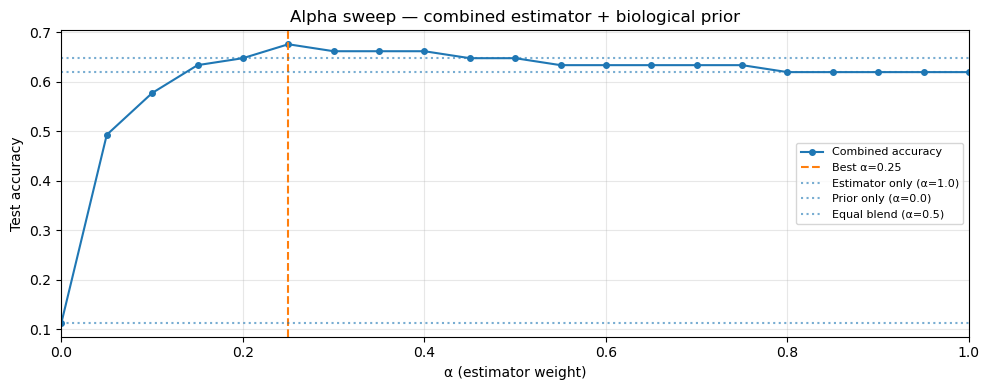

In [26]:
# ── Alpha baselines & sweep (single predict pass, then blend) ─────────────────
y_true = y_est_test_aligned

est_probs     = estimator.predict(X_est_test_norm, verbose=0)       # (N, NUM_SIZE_BINS)
species_probs = classifier.predict(X_test_75, verbose=0)            # (N, NUM_SPECIES)
prior_scores  = species_probs @ SPECIES_SIZE_PRIOR                    # (N, NUM_SIZE_BINS)


def blend_and_predict(alpha):
    combined = alpha * est_probs + (1.0 - alpha) * prior_scores
    return np.argmax(combined, axis=1)


def bin_accuracy(preds):
    return np.mean(preds == y_true)


# ── Baselines ─────────────────────────────────────────────────────────────────
ALPHA_BASELINES = [
    (1.0, 'Estimator only (α=1.0)'),
    (0.0, 'Prior only (α=0.0)'),
    (0.5, 'Equal blend (α=0.5)'),
]

print('Alpha baselines (aligned test set):')
for alpha, label in ALPHA_BASELINES:
    acc = bin_accuracy(blend_and_predict(alpha))
    print(f'  {label:<28} {acc:.2%}')

# ── Sweep ─────────────────────────────────────────────────────────────────────
ALPHAS = np.round(np.arange(0.0, 1.01, 0.05), 2)
sweep_acc = [bin_accuracy(blend_and_predict(a)) for a in ALPHAS]

best_idx   = int(np.argmax(sweep_acc))
BEST_ALPHA = float(ALPHAS[best_idx])
best_acc   = sweep_acc[best_idx]

print(f'\nBest α = {BEST_ALPHA:.2f}  →  accuracy {best_acc:.2%}')

# ── Plot sweep ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ALPHAS, sweep_acc, marker='o', markersize=4, label='Combined accuracy')
ax.axvline(BEST_ALPHA, color='C1', ls='--', label=f'Best α={BEST_ALPHA:.2f}')
for alpha, label in ALPHA_BASELINES:
    acc = bin_accuracy(blend_and_predict(alpha))
    ax.axhline(acc, ls=':', alpha=0.6, label=label)
ax.set_xlabel('α (estimator weight)')
ax.set_ylabel('Test accuracy')
ax.set_title('Alpha sweep — combined estimator + biological prior')
ax.set_xlim(0, 1)
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Predictions at best α for confusion matrix below
pred_bins = blend_and_predict(BEST_ALPHA)


### Confusion matrix — combined pipeline (best α from sweep)

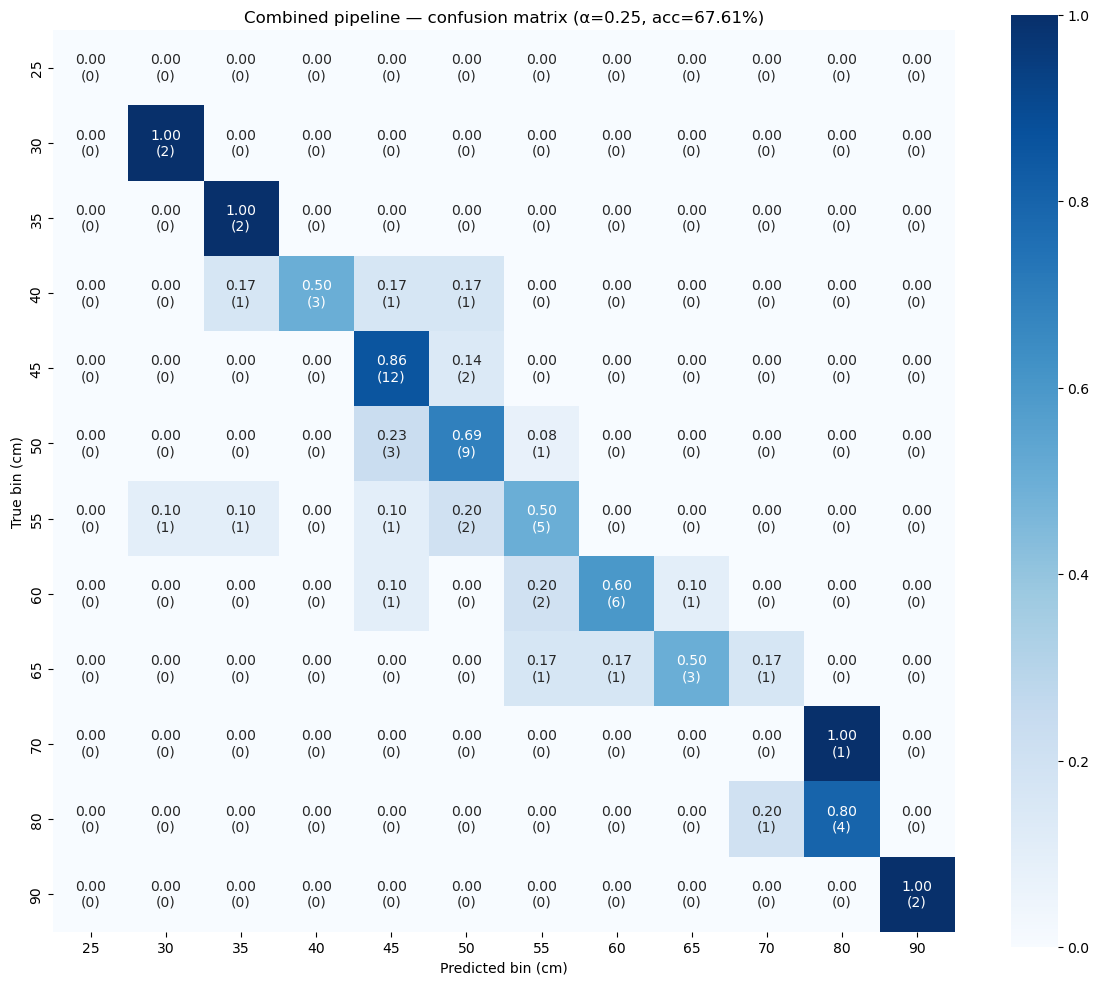

In [27]:
cm      = confusion_matrix(y_est_test_aligned, pred_bins, labels=list(range(NUM_SIZE_BINS)))
row_sum = cm.sum(axis=1, keepdims=True)
cm_norm = np.where(row_sum == 0, 0, cm.astype('float') / np.where(row_sum == 0, 1, row_sum))
annot   = np.array([[f'{cm_norm[i,j]:.2f}\n({cm[i,j]})' for j in range(NUM_SIZE_BINS)]
                     for i in range(NUM_SIZE_BINS)])

plt.figure(figsize=(12, 10))
sns.heatmap(cm_norm, xticklabels=BIN_LABELS, yticklabels=BIN_LABELS,
            cmap='Blues', annot=annot, fmt='', square=True, vmin=0, vmax=1)
plt.title(f'Combined pipeline — confusion matrix (α={BEST_ALPHA:.2f}, acc={best_acc:.2%})')
plt.ylabel('True bin (cm)'); plt.xlabel('Predicted bin (cm)')
plt.tight_layout(); plt.show()


# Eval Code

In [28]:
# ── 20-run evaluation of combined pipeline (using BEST_ALPHA from sweep) ──────

NUM_RUNS = 20
AUTOTUNE = tf.data.AUTOTUNE

# 1. Pool ALL data at both resolutions ─────────────────────────────────────────
print('Pooling all data at 224x224 for estimator...')
X_all_224, y_all_bins = folds_to_arrays(train_folds + test_folds)

print('Pooling all data at 75x200 for classifier...')
X_all_75 = []
y_all_species = []
for fold in (train_folds + test_folds):
    for i, raw in enumerate(fold['data']):
        length = fold['length'][i]
        if length is None or str(length).strip() in ('', 'NA'): continue
        bin_idx = length_to_bin(float(length))
        if bin_idx is None: continue
        species = fold['class'][i]
        for v in range(raw.shape[0]):
            img_75 = raw[v].astype(np.float32) / 255.0
            X_all_75.append(img_75)
            y_all_species.append(species)

X_all_75 = np.array(X_all_75, dtype=np.float32)
y_all_species = np.array(y_all_species)
print(f'Total: {X_all_224.shape[0]} images (224x224), {X_all_75.shape[0]} images (75x200)\n')

assert len(X_all_224) == len(X_all_75), "Image counts don't match — check filtering logic"

# 2. Run loop ──────────────────────────────────────────────────────────────────
results = []
all_cm_combined  = np.zeros((NUM_SIZE_BINS, NUM_SIZE_BINS), dtype=np.float64)
all_cm_estimator = np.zeros((NUM_SIZE_BINS, NUM_SIZE_BINS), dtype=np.float64)

print(f'Using BEST_ALPHA = {BEST_ALPHA:.2f} from sweep\n')

for run in range(NUM_RUNS):
    seed = run
    print(f'═══ Run {run + 1}/{NUM_RUNS}  (seed={seed}) ═══')

    # Split at image level (matching Silva)
    idx = np.arange(len(X_all_224))
    idx_tr, idx_temp = train_test_split(idx, test_size=0.2, random_state=seed)
    idx_val, idx_te  = train_test_split(idx_temp, test_size=0.5, random_state=seed)

    X_tr_224 = X_all_224[idx_tr]
    y_tr     = y_all_bins[idx_tr]
    X_v_224  = X_all_224[idx_val]
    y_v      = y_all_bins[idx_val]
    X_te_224 = X_all_224[idx_te]
    X_te_75  = X_all_75[idx_te]
    y_te     = y_all_bins[idx_te]

    # Build datasets for estimator training
    train_ds = (tf.data.Dataset.from_tensor_slices((X_tr_224, y_tr))
                .shuffle(len(X_tr_224), seed=seed).batch(BATCH_SIZE).prefetch(AUTOTUNE))
    val_ds   = (tf.data.Dataset.from_tensor_slices((X_v_224, y_v))
                .batch(BATCH_SIZE).prefetch(AUTOTUNE))

    # Fresh estimator each run
    model = build_estimator(NUM_SIZE_BINS, trainable_backbone=False)
    model.fit(train_ds, validation_data=val_ds, epochs=ESTIMATOR_EPOCHS, verbose=0)

    # ── Evaluate: estimator only (α=1.0) ──────────────────────────────────
    est_probs = model.predict(X_te_224, verbose=0)
    est_preds = np.argmax(est_probs, axis=1)
    est_acc   = np.mean(est_preds == y_te)

    # ── Evaluate: combined (α=BEST_ALPHA) ─────────────────────────────────
    sp_probs     = classifier.predict(X_te_75, verbose=0)
    prior_scores = sp_probs @ SPECIES_SIZE_PRIOR
    combined     = BEST_ALPHA * est_probs + (1 - BEST_ALPHA) * prior_scores
    comb_preds   = np.argmax(combined, axis=1)
    comb_acc     = np.mean(comb_preds == y_te)

    results.append({
        'run': run + 1,
        'seed': seed,
        'estimator_acc': est_acc,
        'combined_acc': comb_acc,
    })
    print(f'  Estimator acc: {est_acc:.2%}  Combined acc: {comb_acc:.2%}\n')

    # Accumulate normalised confusion matrices
    for preds, cm_accum in [(est_preds, all_cm_estimator), (comb_preds, all_cm_combined)]:
        cm = confusion_matrix(y_te, preds, labels=list(range(NUM_SIZE_BINS)))
        row_sum = cm.sum(axis=1, keepdims=True)
        cm_norm = np.where(row_sum == 0, 0, cm / np.where(row_sum == 0, 1, row_sum))
        cm_accum += cm_norm

    # Free memory
    del model, est_probs, sp_probs, X_tr_224, X_v_224, X_te_224, X_te_75
    tf.keras.backend.clear_session()

Pooling all data at 224x224 for estimator...
  Loaded 6237 images from 693 fish, skipped 1 fish
Pooling all data at 75x200 for classifier...
Total: 6237 images (224x224), 6237 images (75x200)

Using BEST_ALPHA = 0.25 from sweep

═══ Run 1/20  (seed=0) ═══
  Estimator acc: 59.94%  Combined acc: 59.46%

═══ Run 2/20  (seed=1) ═══
  Estimator acc: 55.45%  Combined acc: 54.49%

═══ Run 3/20  (seed=2) ═══
  Estimator acc: 56.25%  Combined acc: 56.25%

═══ Run 4/20  (seed=3) ═══
  Estimator acc: 60.10%  Combined acc: 58.33%

═══ Run 5/20  (seed=4) ═══
  Estimator acc: 60.10%  Combined acc: 58.81%

═══ Run 6/20  (seed=5) ═══
  Estimator acc: 56.57%  Combined acc: 56.57%

═══ Run 7/20  (seed=6) ═══
  Estimator acc: 60.42%  Combined acc: 61.38%

═══ Run 8/20  (seed=7) ═══
  Estimator acc: 58.01%  Combined acc: 57.21%

═══ Run 9/20  (seed=8) ═══
  Estimator acc: 59.29%  Combined acc: 58.49%

═══ Run 10/20  (seed=9) ═══
  Estimator acc: 61.06%  Combined acc: 60.10%

═══ Run 11/20  (seed=10) ═══
 

In [29]:
# ── Summary ───────────────────────────────────────────────────────────────────
import pandas as pd

df = pd.DataFrame(results)
print(df.to_string(index=False))
print(f'\nEstimator only:  {df["estimator_acc"].mean():.2%} ± {df["estimator_acc"].std():.2%}')
print(f'Combined (α={BEST_ALPHA:.2f}): {df["combined_acc"].mean():.2%} ± {df["combined_acc"].std():.2%}')
print(f'Δ accuracy:      {(df["combined_acc"].mean() - df["estimator_acc"].mean()):.2%}')

 run  seed  estimator_acc  combined_acc
   1     0       0.599359      0.594551
   2     1       0.554487      0.544872
   3     2       0.562500      0.562500
   4     3       0.600962      0.583333
   5     4       0.600962      0.588141
   6     5       0.565705      0.565705
   7     6       0.604167      0.613782
   8     7       0.580128      0.572115
   9     8       0.592949      0.584936
  10     9       0.610577      0.600962
  11    10       0.578526      0.580128
  12    11       0.596154      0.589744
  13    12       0.610577      0.600962
  14    13       0.616987      0.608974
  15    14       0.586538      0.573718
  16    15       0.600962      0.594551
  17    16       0.596154      0.604167
  18    17       0.532051      0.527244
  19    18       0.565705      0.551282
  20    19       0.565705      0.554487

Estimator only:  58.61% ± 2.22%
Combined (α=0.25): 57.98% ± 2.31%
Δ accuracy:      -0.63%


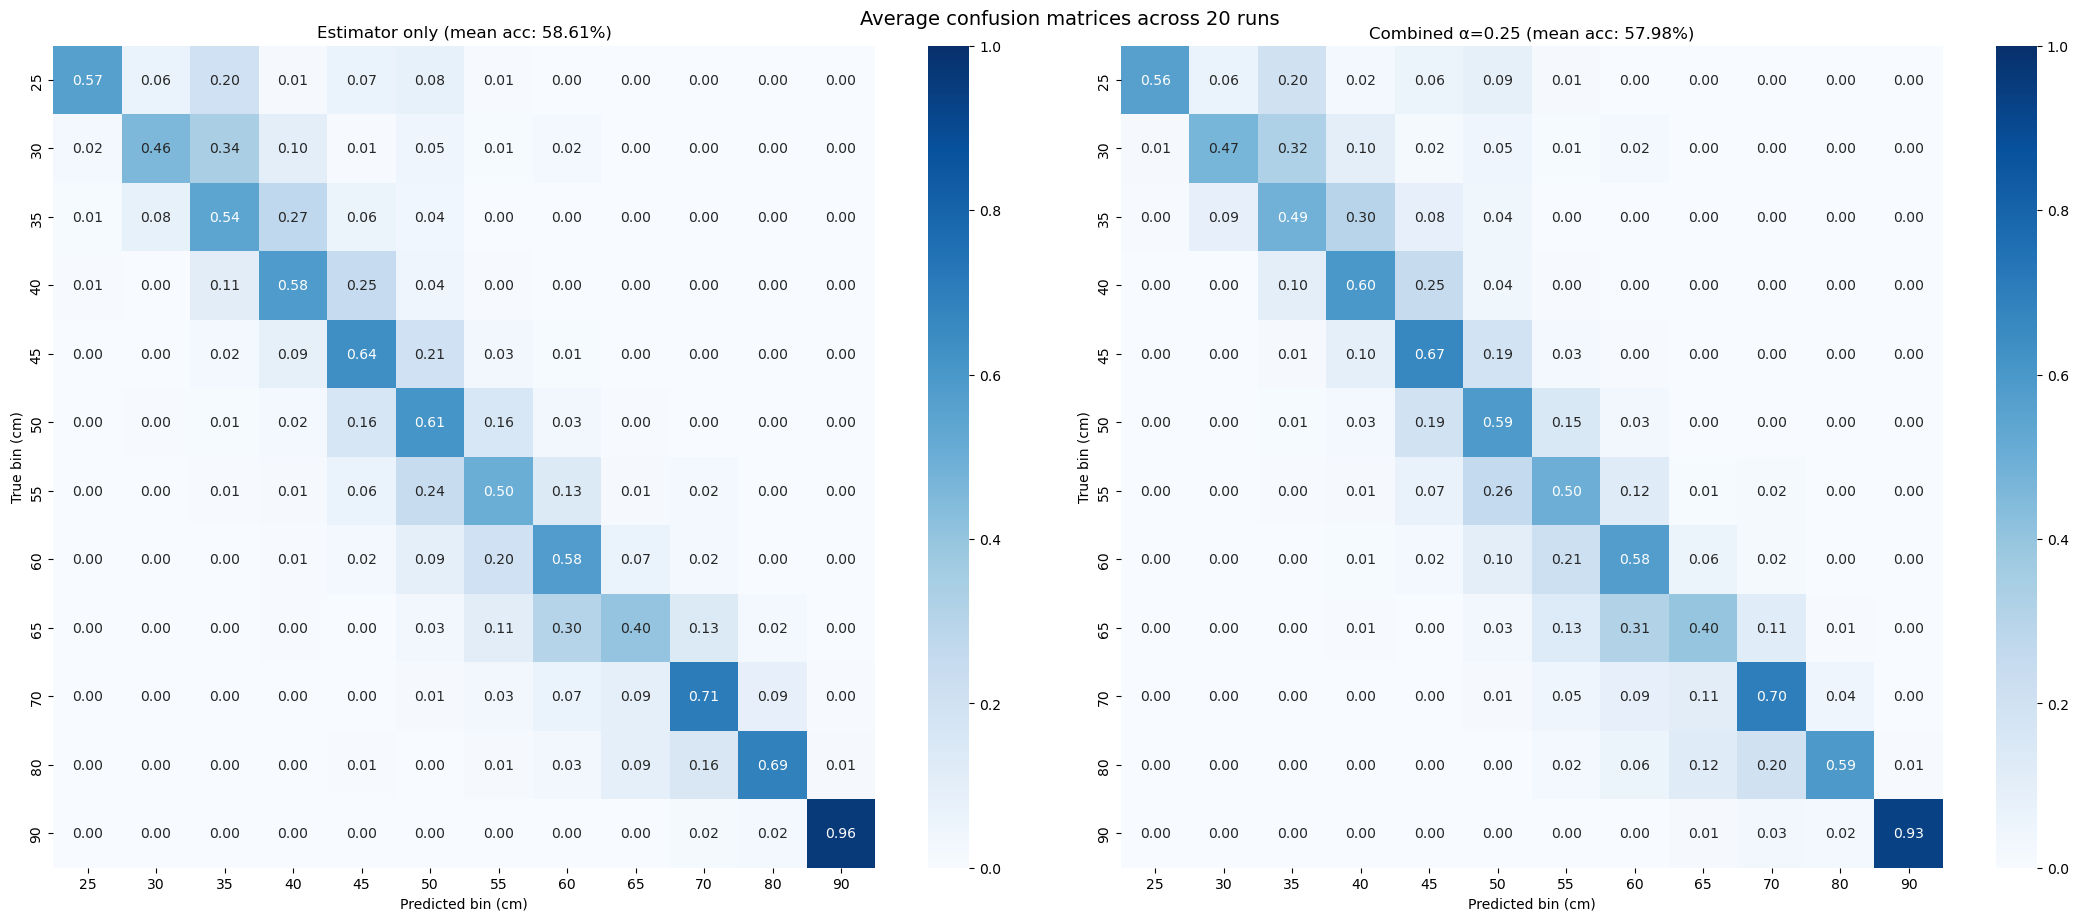

In [30]:
# ── Average confusion matrices ────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))

for ax, cm_accum, title in [
    (ax1, all_cm_estimator, f'Estimator only (mean acc: {df["estimator_acc"].mean():.2%})'),
    (ax2, all_cm_combined,  f'Combined α={BEST_ALPHA:.2f} (mean acc: {df["combined_acc"].mean():.2%})'),
]:
    avg = cm_accum / NUM_RUNS
    sns.heatmap(avg, xticklabels=BIN_LABELS, yticklabels=BIN_LABELS,
                cmap='Blues', annot=True, fmt='.2f', square=True, vmin=0, vmax=1, ax=ax)
    ax.set_title(title)
    ax.set_ylabel('True bin (cm)')
    ax.set_xlabel('Predicted bin (cm)')

plt.suptitle(f'Average confusion matrices across {NUM_RUNS} runs', fontsize=14)
plt.tight_layout()
plt.show()